In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Movies_Cleaned.csv to Movies_Cleaned.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving TVShows_Cleaned.csv to TVShows_Cleaned.csv


In [ ]:
import pandas as pd

movies = pd.read_csv("Movies_Cleaned.csv")
tv = pd.read_csv("TVShows_Cleaned.csv")

print("Movies shape:", movies.shape)
print("TV shape:", tv.shape)

movies.head()

Movies shape: (9515, 17)
TV shape: (5368, 17)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,Age_Min,RottenTomatoes_Score
0,1,The Irishman,2019,18+,98/100,1,0,0,0,0,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,18.0,98.0
1,2,Dangal,2016,7+,97/100,1,0,0,0,0,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,7.0,97.0
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,7.0,95.0
3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0,"Drama, Musical, Sport","India, United States","Hindi, English",8.1,tt0169102,7.0,94.0
4,5,Roma,2018,18+,94/100,1,0,0,0,0,Drama,"Mexico, United States","Spanish, Mixtec, English, Japanese, German, Fr...",7.6,tt6155172,18.0,94.0


In [ ]:
print(movies.columns)
print(tv.columns)

print("\nMissing values (Movies):")
print(movies.isna().sum().sort_values(ascending=False).head())

print("\nMissing values (TV):")
print(tv.isna().sum().sort_values(ascending=False).head())

Index(['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu',
       'Prime Video', 'Disney+', 'Type', 'Genre', 'Country', 'Language',
       'IMDb', 'IMDb_ID', 'Age_Min', 'RottenTomatoes_Score'],
      dtype='object')
Index(['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu',
       'Prime Video', 'Disney+', 'Type', 'Genre', 'Country', 'Language',
       'IMDb', 'IMDb_ID', 'Age_Min', 'RottenTomatoes_Score'],
      dtype='object')

Missing values (Movies):
ID                 0
Title              0
Year               0
Age                0
Rotten Tomatoes    0
dtype: int64

Missing values (TV):
ID                 0
Title              0
Year               0
Age                0
Rotten Tomatoes    0
dtype: int64


In [ ]:
movies["Type"] = "Movie"
tv["Type"] = "TV Show"

df = pd.concat([movies, tv], ignore_index=True)

print("Combined shape:", df.shape)
df.head()

Combined shape: (14883, 17)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,Age_Min,RottenTomatoes_Score
0,1,The Irishman,2019,18+,98/100,1,0,0,0,Movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,18.0,98.0
1,2,Dangal,2016,7+,97/100,1,0,0,0,Movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,7.0,97.0
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,Movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,7.0,95.0
3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,Movie,"Drama, Musical, Sport","India, United States","Hindi, English",8.1,tt0169102,7.0,94.0
4,5,Roma,2018,18+,94/100,1,0,0,0,Movie,Drama,"Mexico, United States","Spanish, Mixtec, English, Japanese, German, Fr...",7.6,tt6155172,18.0,94.0


In [ ]:
platform_cols = ["Netflix", "Hulu", "Prime Video", "Disney+"]

df_long = df.melt(
    id_vars=[col for col in df.columns if col not in platform_cols],
    value_vars=platform_cols,
    var_name="Platform",
    value_name="On_Platform"
)

df_long = df_long[df_long["On_Platform"] == 1].drop(columns=["On_Platform"])

print("Original rows:", len(df))
print("Long format rows:", len(df_long))

df_long.head()

Original rows: 14883
Long format rows: 15551


,ID,Title,Year,Age,Rotten Tomatoes,Type,Genre,Country,Language,IMDb,IMDb_ID,Age_Min,RottenTomatoes_Score,Platform
0,1,The Irishman,2019,18+,98/100,Movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,18.0,98.0,Netflix
1,2,Dangal,2016,7+,97/100,Movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,7.0,97.0,Netflix
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,Movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,7.0,95.0,Netflix
3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,Movie,"Drama, Musical, Sport","India, United States","Hindi, English",8.1,tt0169102,7.0,94.0,Netflix
4,5,Roma,2018,18+,94/100,Movie,Drama,"Mexico, United States","Spanish, Mixtec, English, Japanese, German, Fr...",7.6,tt6155172,18.0,94.0,Netflix


In [ ]:
netflix_df = df[df["Netflix"] == 1].copy()

print("Netflix titles:", netflix_df.shape)
netflix_df.head()

Netflix titles: (5666, 17)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,Age_Min,RottenTomatoes_Score
0,1,The Irishman,2019,18+,98/100,1,0,0,0,Movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,18.0,98.0
1,2,Dangal,2016,7+,97/100,1,0,0,0,Movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,7.0,97.0
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,Movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,7.0,95.0
3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,Movie,"Drama, Musical, Sport","India, United States","Hindi, English",8.1,tt0169102,7.0,94.0
4,5,Roma,2018,18+,94/100,1,0,0,0,Movie,Drama,"Mexico, United States","Spanish, Mixtec, English, Japanese, German, Fr...",7.6,tt6155172,18.0,94.0


In [ ]:
print("Movies vs TV:")
print(netflix_df["Type"].value_counts())

print("\nYear range:")
print(netflix_df["Year"].min(), "-", netflix_df["Year"].max())

Movies vs TV:
Type
Movie      3695
TV Show    1971
Name: count, dtype: int64

Year range:
1954 - 2021


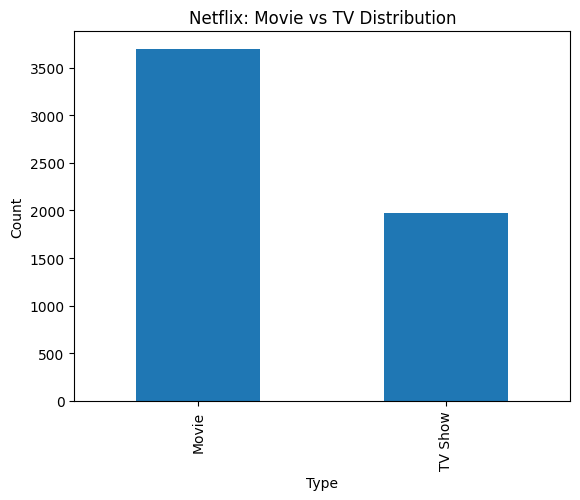

In [ ]:
import matplotlib.pyplot as plt

netflix_df["Type"].value_counts().plot(kind="bar")
plt.title("Netflix: Movie vs TV Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

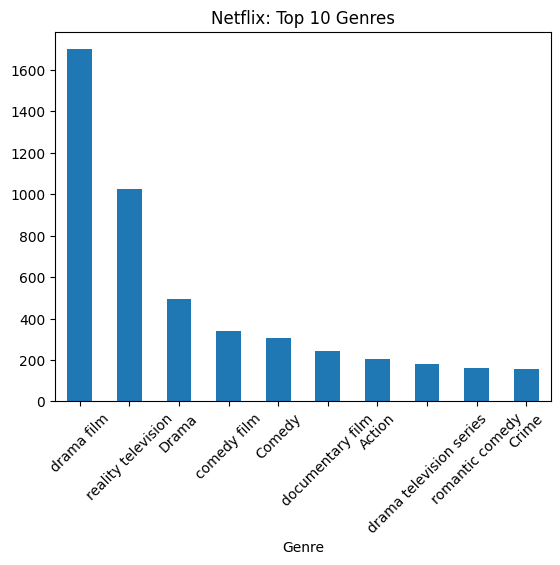

In [ ]:
genres = (
    netflix_df["Genre"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

top_genres = genres.value_counts().head(10)

top_genres.plot(kind="bar")
plt.title("Netflix: Top 10 Genres")
plt.xticks(rotation=45)
plt.show()

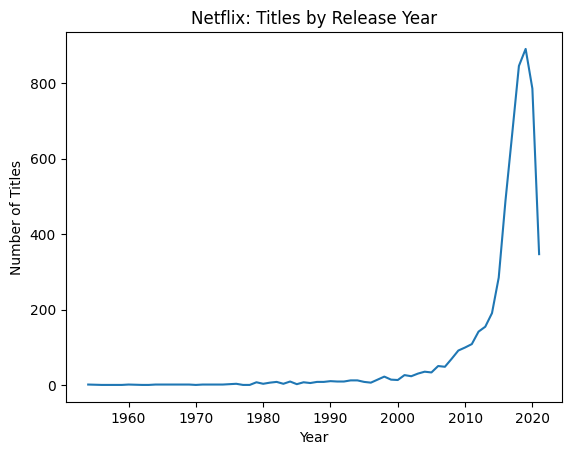

In [ ]:
netflix_df["Year"] = pd.to_numeric(netflix_df["Year"], errors="coerce")

year_counts = netflix_df.groupby("Year")["Title"].nunique()

year_counts.sort_index().plot()
plt.title("Netflix: Titles by Release Year")
plt.ylabel("Number of Titles")
plt.show()

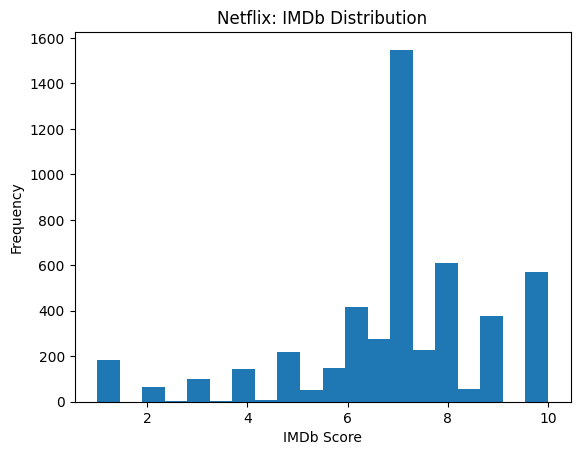

Average IMDb: 6.95


In [ ]:
netflix_df["IMDb"] = pd.to_numeric(netflix_df["IMDb"], errors="coerce")

netflix_df["IMDb"].dropna().plot(kind="hist", bins=20)
plt.title("Netflix: IMDb Distribution")
plt.xlabel("IMDb Score")
plt.show()

print("Average IMDb:", round(netflix_df["IMDb"].mean(), 2))

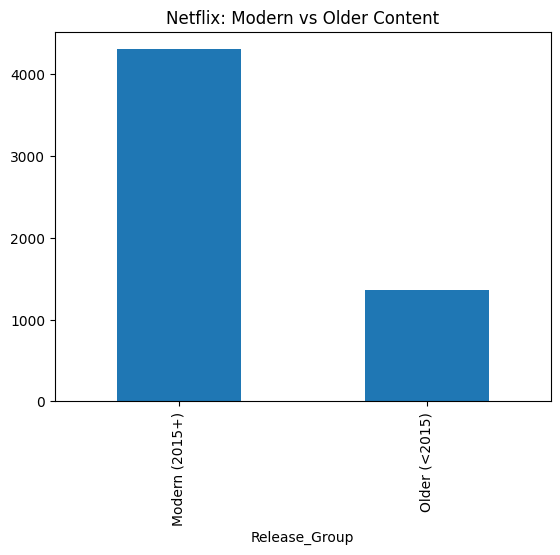

In [ ]:
netflix_df["Release_Group"] = netflix_df["Year"].apply(
    lambda x: "Modern (2015+)" if x >= 2015 else "Older (<2015)"
)

netflix_df["Release_Group"].value_counts().plot(kind="bar")
plt.title("Netflix: Modern vs Older Content")
plt.show()

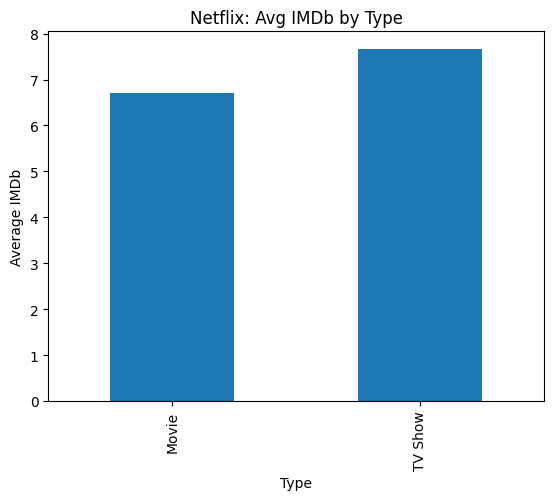

In [ ]:
netflix_df.groupby("Type")["IMDb"].mean().plot(kind="bar")
plt.title("Netflix: Avg IMDb by Type")
plt.ylabel("Average IMDb")
plt.show()



**Strengths:** Netflix has a large, diverse catalog with mostly modern content and steady mid-to-high quality ratings.

**Weaknesses:** It focuses heavily on volume, which may reduce exclusivity and premium perception.

**Opportunities:** Netflix can invest more in high-rated prestige content and expand successful genres globally.

**Threats:** Strong competition and rising production costs could challenge its growth and differentiation.

